--- Initial Data Overview ---
First 5 rows of the dataset:
   Person ID Gender  Age            Occupation  Sleep Duration  \
0          1   Male   27     Software Engineer             6.1   
1          2   Male   28                Doctor             6.2   
2          3   Male   28                Doctor             6.2   
3          4   Male   28  Sales Representative             5.9   
4          5   Male   28  Sales Representative             5.9   

   Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                 6                       42             6   Overweight   
1                 6                       60             8       Normal   
2                 6                       60             8       Normal   
3                 4                       30             8        Obese   
4                 4                       30             8        Obese   

  Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
0         126/83          77      

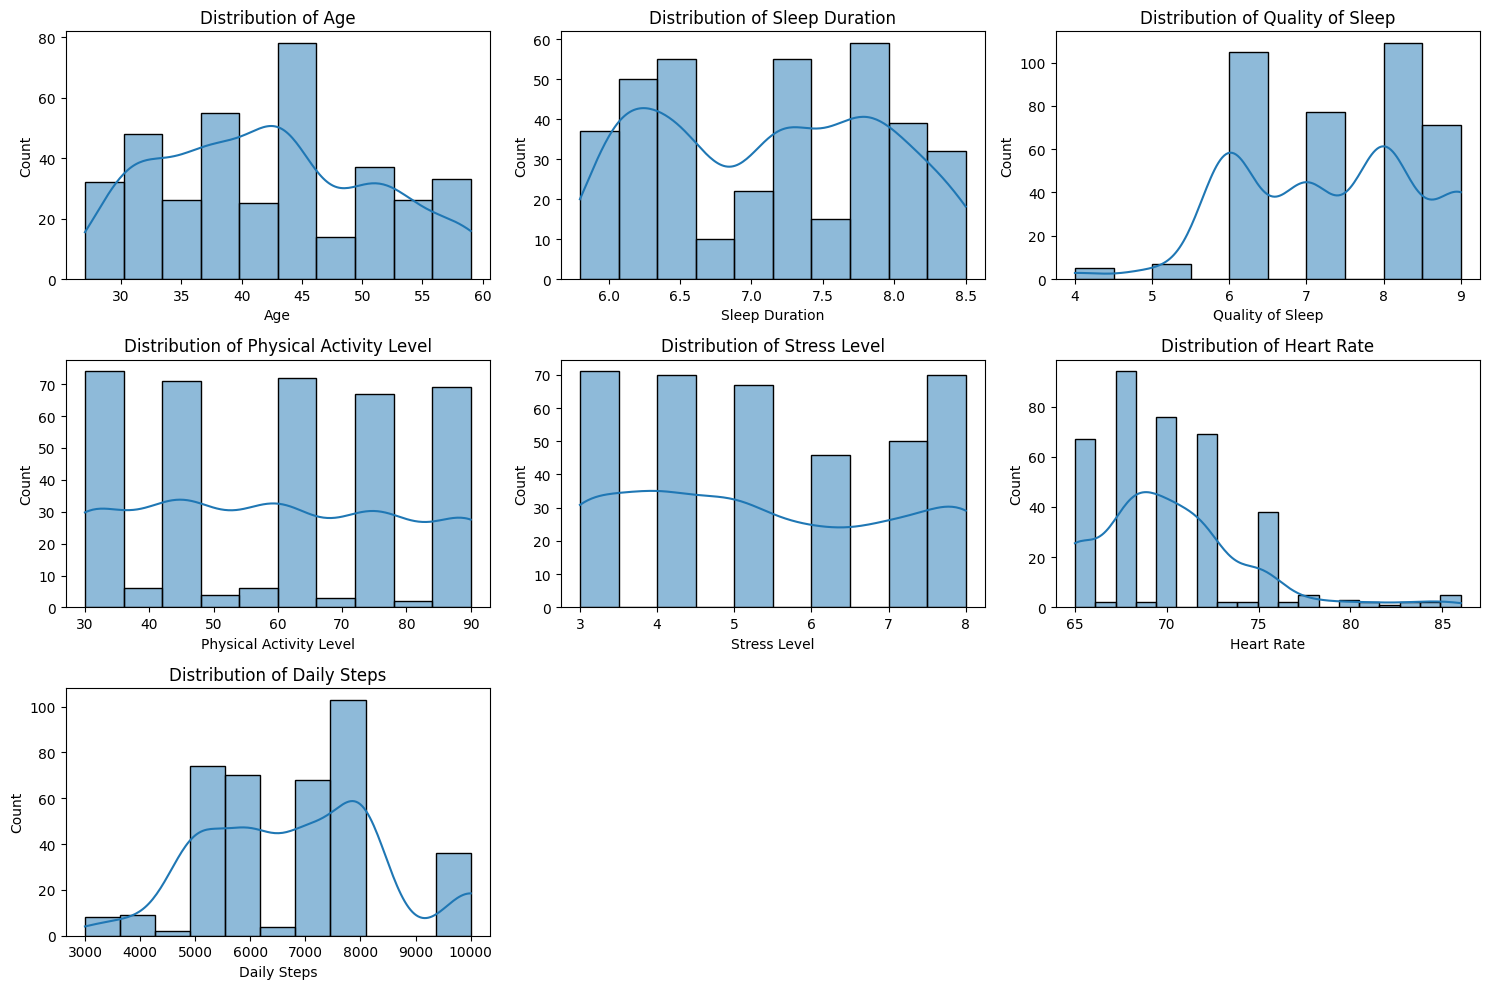

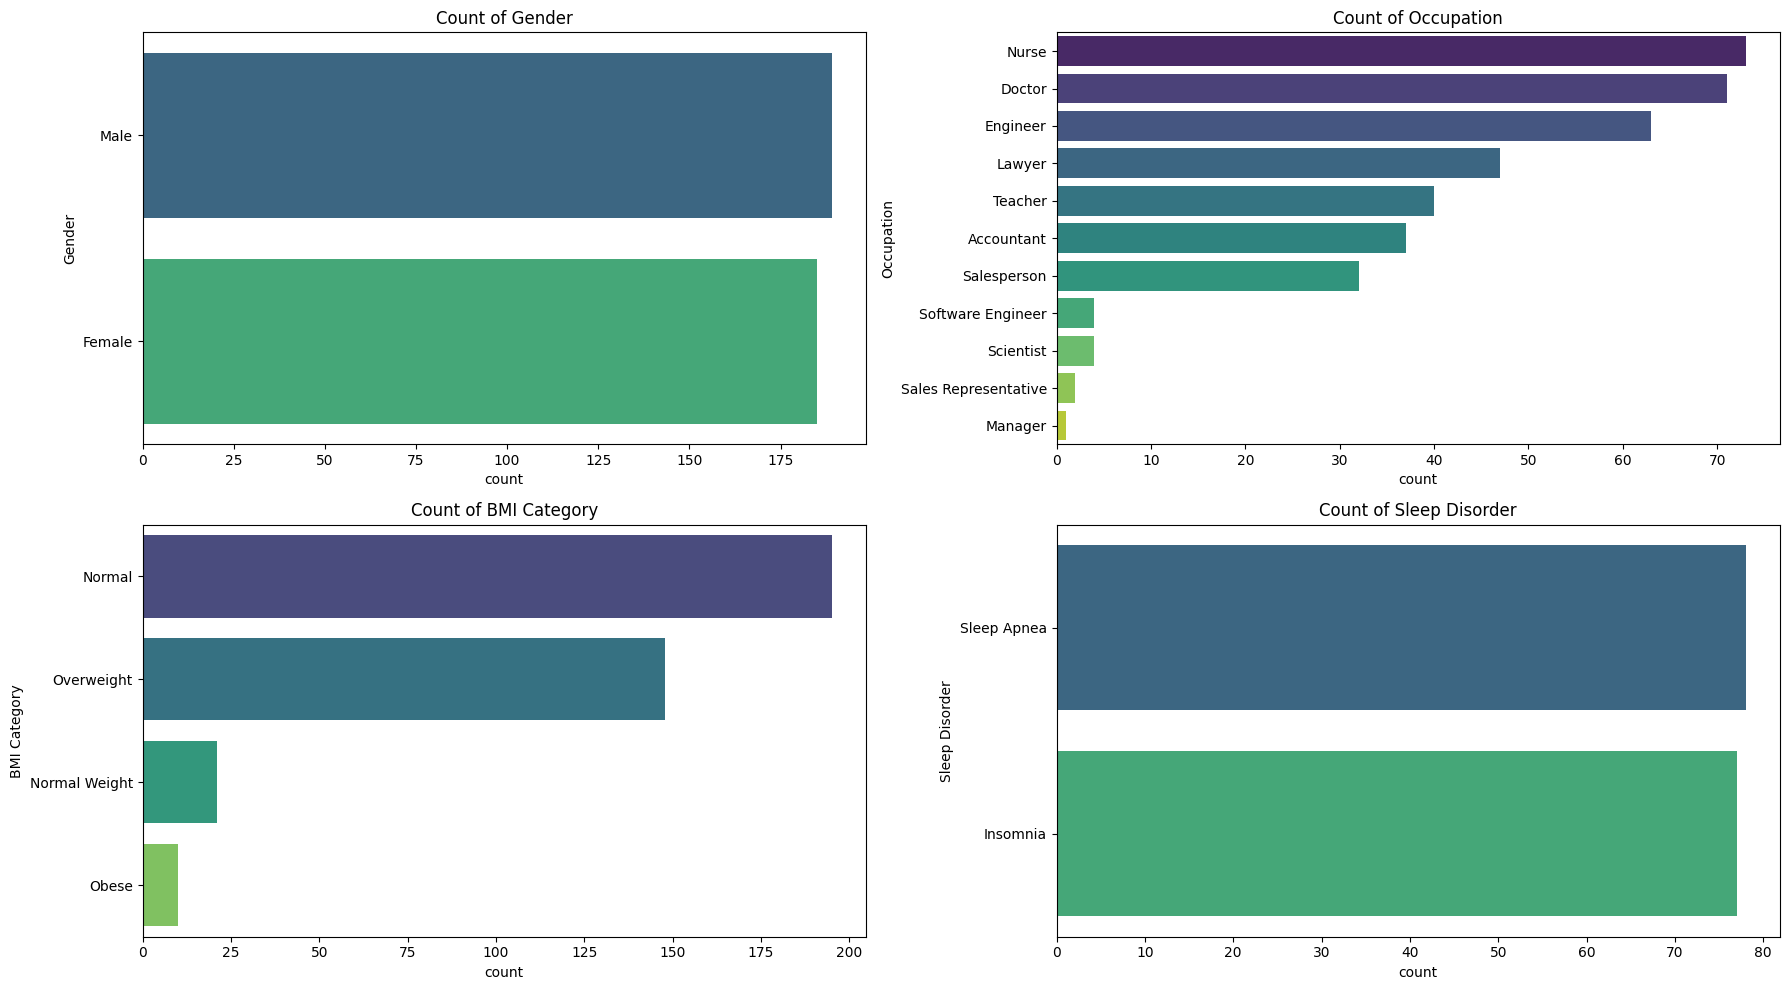

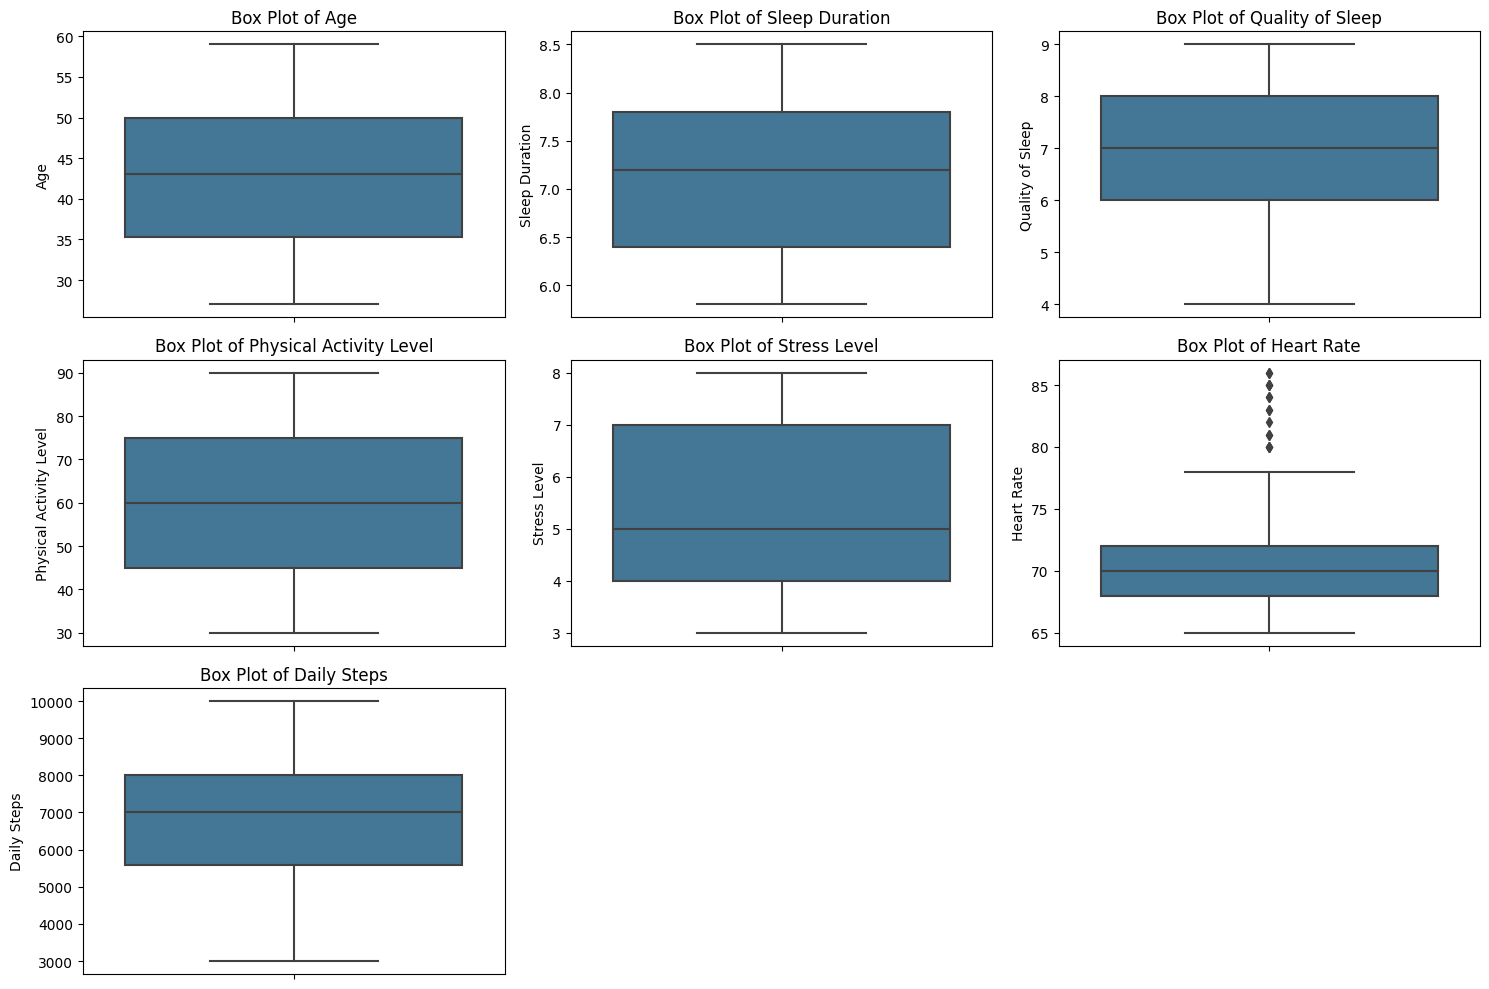

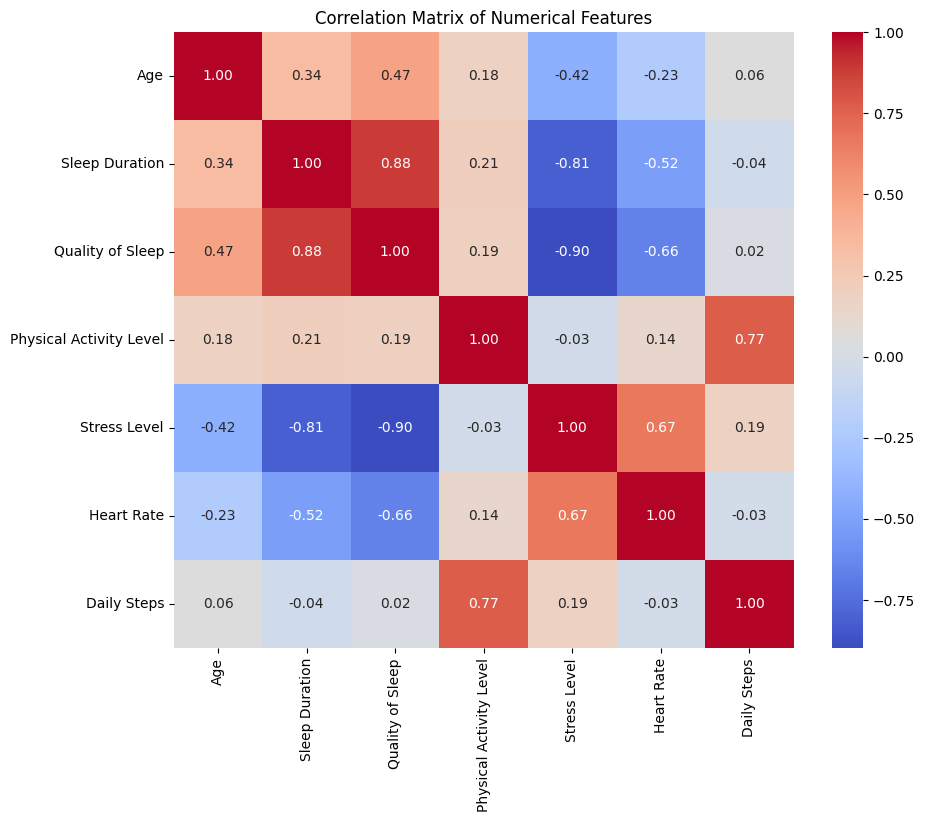

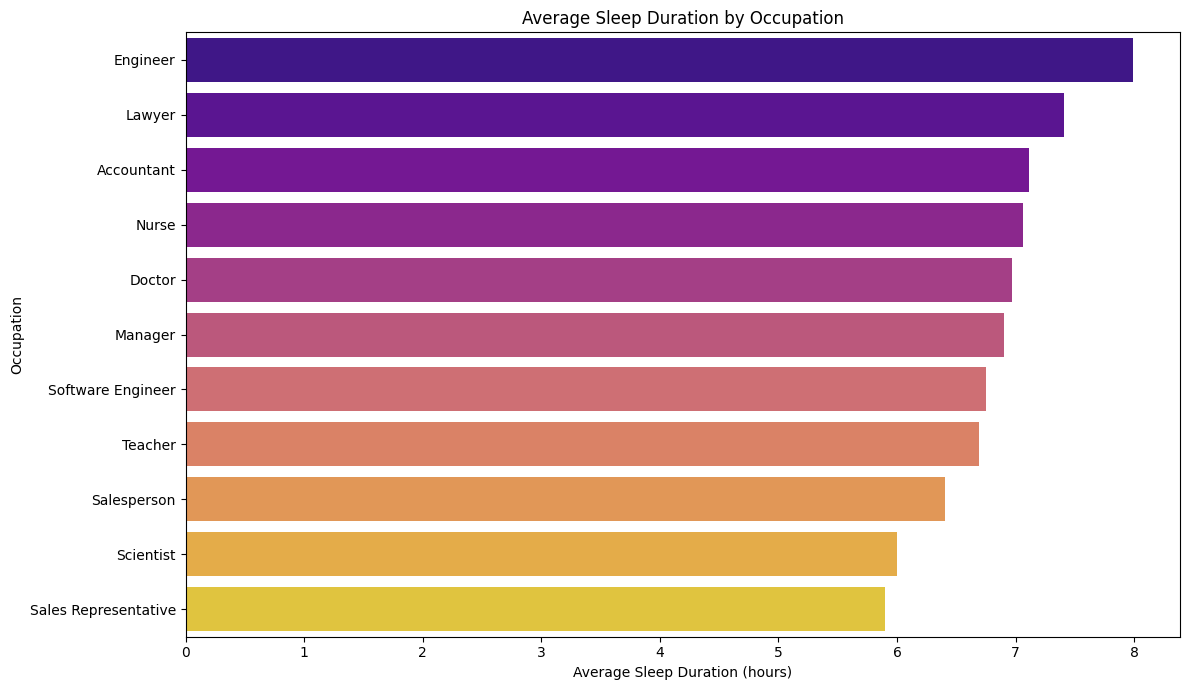

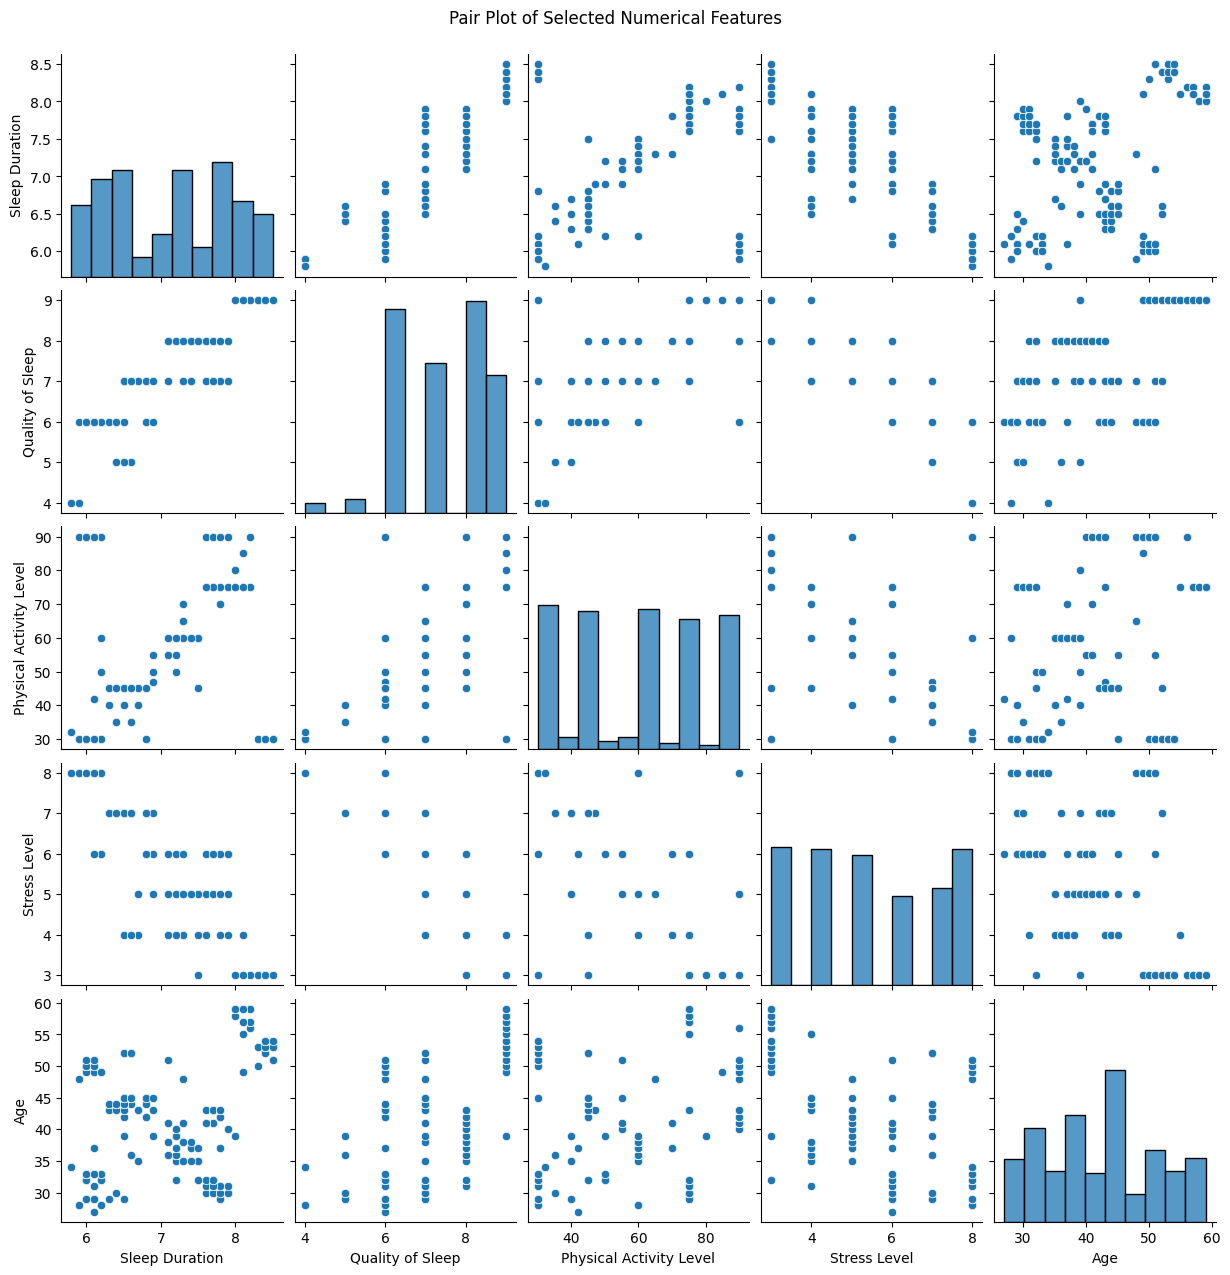

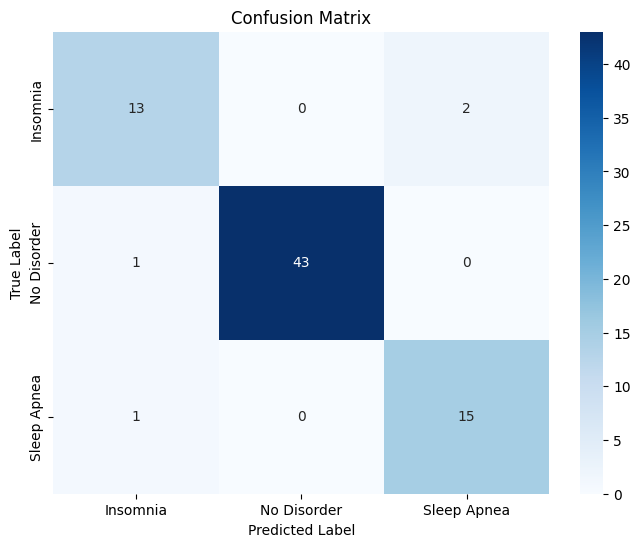

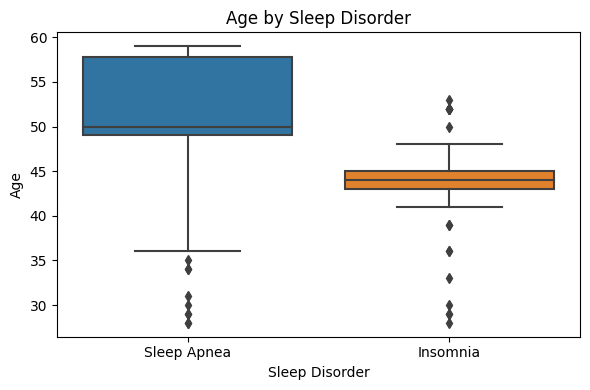

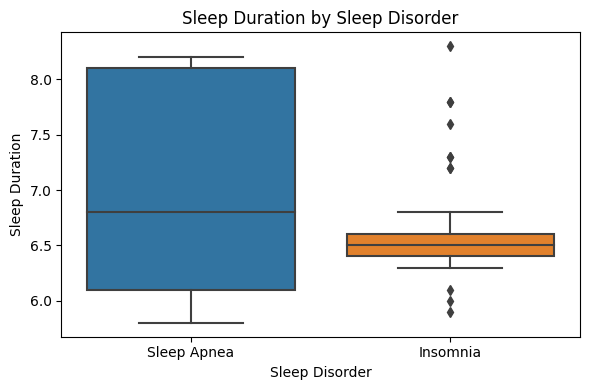

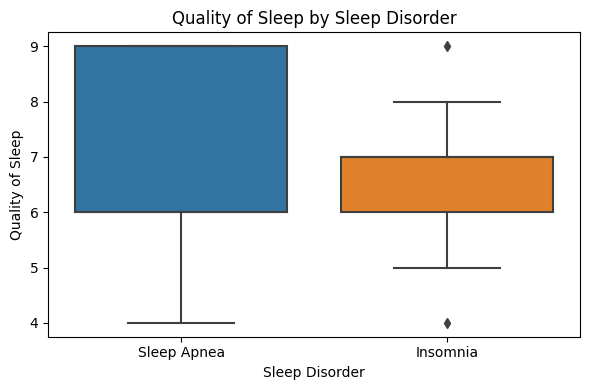

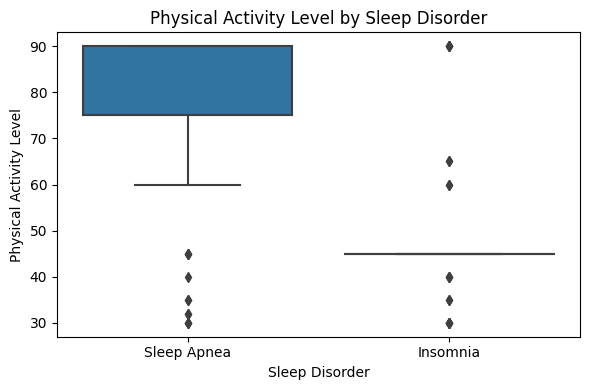

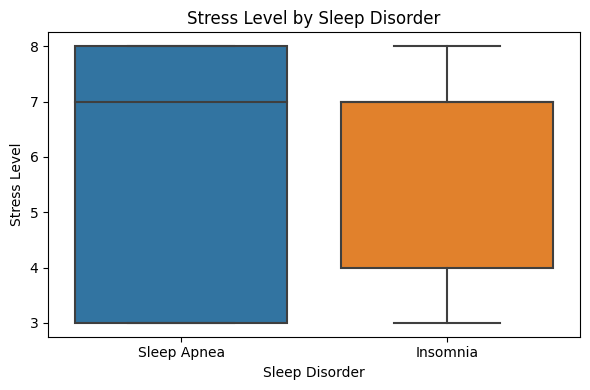

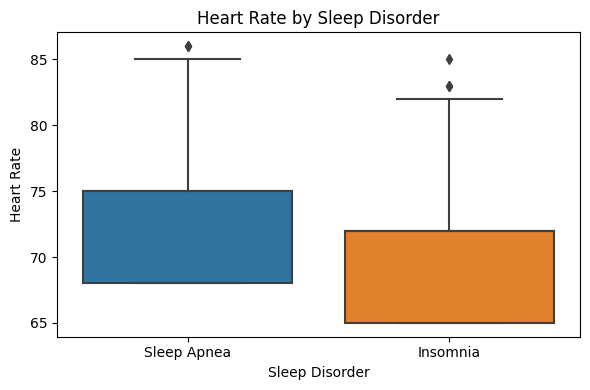

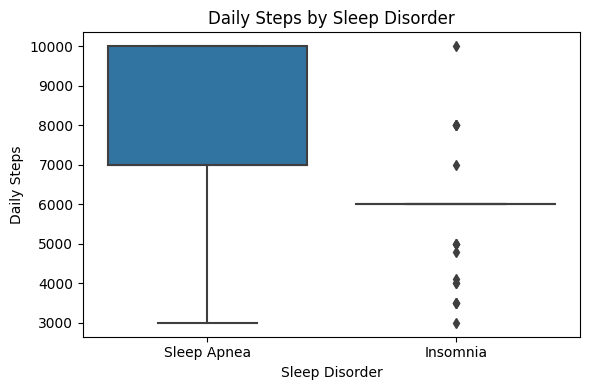

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings

warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('/kaggle/input/sleep-health-and-lifestyle-dataset/Sleep_health_and_lifestyle_dataset.csv')

print("--- Initial Data Overview ---")
print("First 5 rows of the dataset:")
print(df.head())
print("\nInformation about the dataset:")
print(df.info())

# --- EDA ---
print("\n--- Exploratory Data Analysis (EDA) ---")
print("\nSummary Statistics for Numerical Columns:")
print(df.describe())

print("\nValue Counts for Categorical Columns:")
for col in ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']:
    print(f"\n{col}:")
    print(df[col].value_counts())

print("\nMissing Value Check:")
print(df.isnull().sum())

print("\nUnique Value Counts for all columns:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Visualizations
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numerical_distributions.png')

categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.savefig('categorical_distributions.png')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], palette='mako')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.savefig('numerical_boxplots.png')

df_numerical = df[numerical_cols]
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('correlation_heatmap.png')

print("\nAverage Sleep Duration by Occupation:")
print(df.groupby('Occupation')['Sleep Duration'].mean().sort_values(ascending=False))

print("\nAverage Quality of Sleep by BMI Category:")
print(df.groupby('BMI Category')['Quality of Sleep'].mean().sort_values(ascending=False))

plt.figure(figsize=(12, 7))
sns.barplot(x='Sleep Duration', y='Occupation', 
            data=df.groupby('Occupation')['Sleep Duration'].mean().reset_index().sort_values(by='Sleep Duration', ascending=False), 
            palette='plasma')
plt.title('Average Sleep Duration by Occupation')
plt.xlabel('Average Sleep Duration (hours)')
plt.ylabel('Occupation')
plt.tight_layout()
plt.savefig('sleep_duration_by_occupation.png')

selected_for_pairplot = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Age']
sns.pairplot(df[selected_for_pairplot])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.savefig('pairplot_selected_features.png')


# --- Data Preprocessing ---
print("\n--- Data Preprocessing ---")
df_processed = df.copy()

# Process 'Blood Pressure' column
df_processed[['Systolic Blood Pressure', 'Diastolic Blood Pressure']] = df_processed['Blood Pressure'].str.split('/', expand=True)
df_processed['Systolic Blood Pressure'] = pd.to_numeric(df_processed['Systolic Blood Pressure'], errors='coerce')
df_processed['Diastolic Blood Pressure'] = pd.to_numeric(df_processed['Diastolic Blood Pressure'], errors='coerce')
df_processed.drop('Blood Pressure', axis=1, inplace=True)
print("Processed 'Blood Pressure' column.")

# Replace 'None' and NaN in 'Sleep Disorder' with 'No Disorder'
df_processed['Sleep Disorder'] = df_processed['Sleep Disorder'].replace(['None', np.nan], 'No Disorder')

# Drop remaining rows with any NaNs (optional but safe)
df_processed.dropna(inplace=True)

# Confirm fix
print("\nSleep Disorder value counts after fix:")
print(df_processed['Sleep Disorder'].value_counts())
print("\nRemaining missing values in dataset:")
print(df_processed.isnull().sum())

# Split features and target
X = df_processed.drop(['Person ID', 'Sleep Disorder'], axis=1)
y = df_processed['Sleep Disorder']

# Identify features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Preprocessing pipeline
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nX_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

# --- Model Training ---
print("\n--- Training RandomForestClassifier ---")
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', RandomForestClassifier(random_state=42))])

model.fit(X_train, y_train)
print("Model training complete.")

# --- Evaluation ---
print("\n--- Model Evaluation ---")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.named_steps['classifier'].classes_, 
            yticklabels=model.named_steps['classifier'].classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('confusion_matrix.png')

# Save model
model_filename = 'sleep_disorder_predictor_model.joblib'
joblib.dump(model, model_filename)
print(f"\nModel saved as {model_filename} for Streamlit app.")

# Sample prediction for Streamlit usage
# Uncomment this block in your Streamlit app:
"""
loaded_model = joblib.load('sleep_disorder_predictor_model.joblib')

sample_input_data = {
    'Gender': ['Male'],
    'Age': [35],
    'Occupation': ['Engineer'],
    'Sleep Duration': [7.5],
    'Quality of Sleep': [8],
    'Physical Activity Level': [60],
    'Stress Level': [5],
    'BMI Category': ['Normal'],
    'Heart Rate': [70],
    'Daily Steps': [7000],
    'Systolic Blood Pressure': [120],
    'Diastolic Blood Pressure': [80]
}
sample_df = pd.DataFrame(sample_input_data)
prediction = loaded_model.predict(sample_df)
print(f"\nSample prediction: {prediction[0]}")

"""
# Mean values of numeric features by Sleep Disorder type
print("\n--- Average Feature Values by Sleep Disorder ---")
print(df.groupby('Sleep Disorder')[numerical_cols].mean())

# Visualizing differences
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Sleep Disorder', y=col, data=df)
    plt.title(f'{col} by Sleep Disorder')
    plt.tight_layout()
    plt.savefig(f'{col}_by_sleep_disorder.png')
for cat_col in categorical_cols:
    print(f"\n--- Cross-tab: {cat_col} vs Sleep Disorder ---")
    print(pd.crosstab(df[cat_col], df['Sleep Disorder'], normalize='index') * 100)


